# Regional wave-mode variance

For each named tropical wave mode (MJO, Kelvin, ER1, MRG, plus a broad `AllWave` band), reconstruct the field's contribution to that mode via wavenumber-frequency filtering + inverse FFT, then map its variance over ±45° lat and 0-360° lon (centered at 180°).

Python port of `/glade/u/home/rneale/ncl/CESM3_CAM7/wave_var/wave_var_cesm3_tiedke.ncl`.  Uses the loaders from `kf_pan_utils` so the case list matches the WK diagnostic.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('wave_var_utils.py')))
sys.path.insert(0, '/glade/work/rneale/git/python-scripts/trop_hf_variability/kf_pan')

import importlib
import numpy as np
import matplotlib.pyplot as plt

import kf_pan_utils as kfp
import wave_var_utils as wvu
importlib.reload(kfp); importlib.reload(wvu)

<module 'wave_var_utils' from '/glade/work/rneale/git/python-scripts/trop_hf_variability/wave_var/wave_var_utils.py'>

In [2]:
# Optional dask cluster (mirrors the kf_pan notebook — safe to skip)
from dask.distributed import Client
from dask_jobqueue import PBSCluster

cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",
    cores=4,
    memory="32GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-temp",
)
cluster.scale(jobs=16)
client = Client(cluster)
client

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38519 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc70.hpc.ucar.edu/18408/proxy/38519/status,
Dashboard: /node/crhtc70.hpc.ucar.edu/18408/proxy/38519/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.178:46157,Workers: 0
Dashboard: /node/crhtc70.hpc.ucar.edu/18408/proxy/38519/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
# ── Variable ───────────────────────────────────────────────────────────────
VAR0    = 'PRECT'
vscale0 = 86400. * 1000.   # m/s → mm/day for model PRECT

# ── Filtering parameters (mirror the NCL wave_var_cesm3_tiedke.ncl defaults) ──
lat_bound   = 45          # analysis / plotting extent (±deg)
n_day_win   = 365         # 1-year windows
n_day_olap  = 10          # 10-day overlap between windows
n_day_taper = 20          # cosine bell taper length at each end

# ── Modes to compute / plot ───────────────────────────────────────────────
MODES = wvu.MODES         # AllWave, MJO, Kelvin, ER1, MRG
mode_names = list(MODES.keys())

# ── Output ─────────────────────────────────────────────────────────────────
save_dir   = './figs_wave_var'
fig_prefix = 'wave_var'

In [4]:
# ── Cases ──────────────────────────────────────────────────────────────────
# Same shape as the kf_pan notebook: source can be TRMM/GPCP/ERA5/IMERG or a
# CESM case string.  `vscale` converts loaded data to physical units for the
# variance plots (mm/day for precip).
cases = [
    dict(source='TRMM', label='TRMM', yr0=2000, yr1=2009, freq='daily', var='PRECT', vscale=1.0),
    dict(source='GPCP', label='GPCP', yr0=2000, yr1=2009, freq='daily', var='PRECT', vscale=1.0),
    dict(source='b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.315',
         label='315',  yr0=30, yr1=59, freq='daily', var=VAR0, vscale=vscale0),
    dict(source='b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316',
         label='316',  yr0=20, yr1=49, freq='daily', var=VAR0, vscale=vscale0),
]
case_labels = [c['label'] for c in cases]
print('Cases:', case_labels)

Cases: ['TRMM', 'GPCP', '315', '316']


## Load data and compute per-mode variance

In [5]:
vars_by_case = []
case_grids   = []      # (lat, lon) for each case

for ic, case in enumerate(cases):
    src  = case['source']
    lbl  = case['label']
    yr0  = case.get('yr0'); yr1 = case.get('yr1')
    var  = case.get('var', VAR0)
    freq = case.get('freq', 'daily')
    res  = case.get('resolution', '1deg')
    vs   = case.get('vscale', vscale0)

    print(f'\n--- Loading case {ic+1}/{len(cases)}: {lbl} ---')
    x_np, lat, lon, spd = kfp.load_data(
        source=src, var=var, resolution=res, freq=freq,
        yr0=yr0, yr1=yr1, lat_bound=lat_bound,
    )
    x_np = x_np * vs                # convert to physical units before variance
    print(f'  shape={x_np.shape}, spd={spd}, lat=[{lat[0]:+.1f}, {lat[-1]:+.1f}]')

    print('  Computing wave-mode variance ...')
    vars_this = wvu.compute_wave_mode_variance(
        x_np, lat, lon, spd=spd,
        n_day_win=n_day_win, n_day_olap=n_day_olap, n_day_taper=n_day_taper,
        modes=MODES, remove_ac=True, ldetrend=True,
    )
    # attach grid so plotting works with heterogeneous grids across cases
    vars_this['lat'] = lat
    vars_this['lon'] = lon
    vars_by_case.append(vars_this)
    case_grids.append((lat, lon))
    print('  done.')


--- Loading case 1/4: TRMM ---


/glade/work/rneale/git/python-scripts/trop_hf_variability/kf_pan/kf_pan_utils.py:535: FutureWarning: In a future version, xarray will not decode the variable 'datesec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(fpath)


  shape=(3653, 91, 360), spd=1, lat=[-44.1, +44.1]
  Computing wave-mode variance ...
  - filling 14052 NaN cells with column time-means
  - removing day-of-year climatology
  - windowing: N=365, step=355, n_win=10
      mask[AllWave]: 11160 FFT cells (8.49% of grid)
      mask[MJO]: 150 FFT cells (0.11% of grid)
      mask[Kelvin]: 3752 FFT cells (2.86% of grid)
      mask[ER1]: 1020 FFT cells (0.78% of grid)
      mask[MRG]: 2200 FFT cells (1.67% of grid)
  - window 1/10  samples [0:365]
  - window 2/10  samples [355:720]
  - window 3/10  samples [710:1075]
  - window 4/10  samples [1065:1430]
  - window 5/10  samples [1420:1785]
  - window 6/10  samples [1775:2140]
  - window 7/10  samples [2130:2495]
  - window 8/10  samples [2485:2850]
  - window 9/10  samples [2840:3205]
  - window 10/10  samples [3195:3560]
  done.

--- Loading case 2/4: GPCP ---
  shape=(3653, 90, 360), spd=1, lat=[-44.5, +44.5]
  Computing wave-mode variance ...
  - filling 83701 NaN cells with column time-mea

## Plot variance maps (rows = modes, cols = cases)

Saved: figs_wave_var/wave_var_PRECT.png


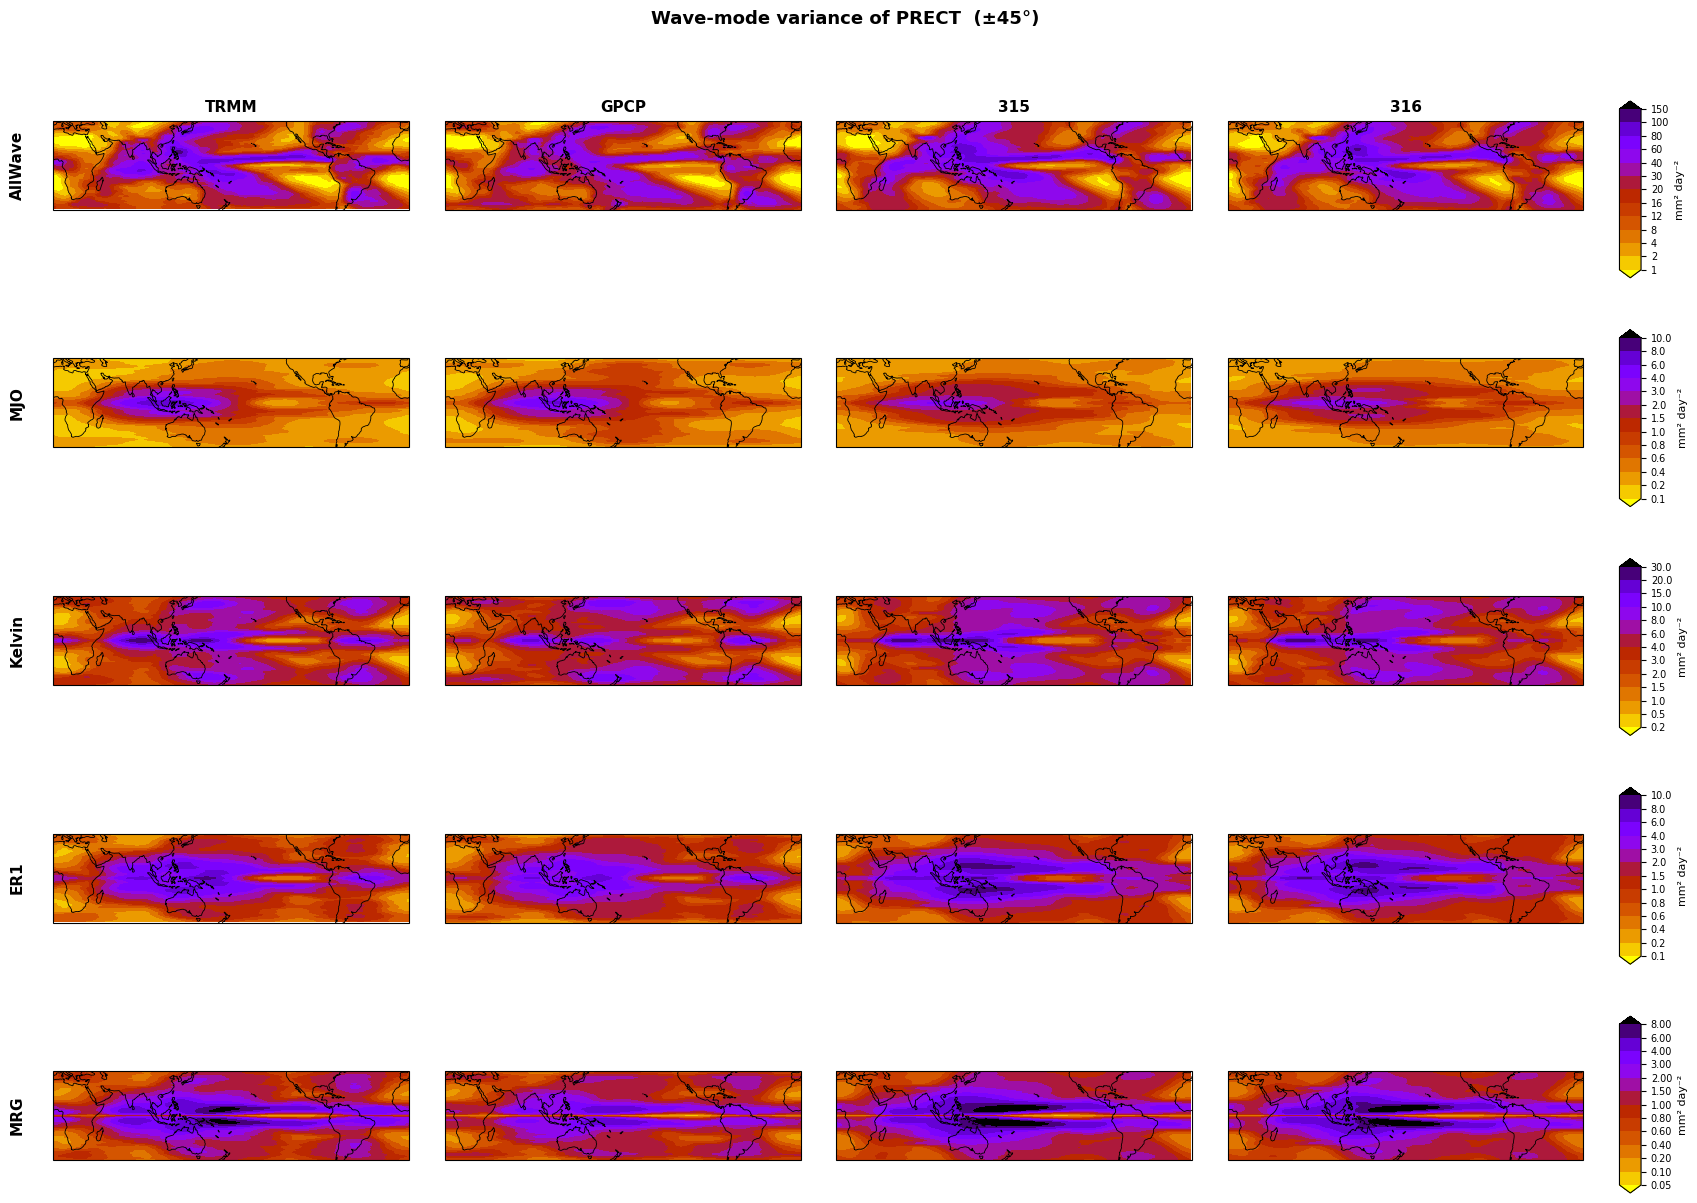

In [9]:
wvu.plot_wave_variance(
    vars_by_case, case_labels,
    mode_names=mode_names,
    var_name=VAR0,
    var_units='mm² day⁻²' if VAR0 == 'PRECT' else 'var',
    lat_range=(-lat_bound, lat_bound),
    lon_center=180,
    save_dir=save_dir,
    fig_prefix=fig_prefix,
)
plt.show()